In [146]:
# Import necessary libraries
import cv2 # OpenCV for reading images
import matplotlib.pyplot as plt # For displaying images
import numpy as np
from sklearn.cluster import KMeans
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

from utils import read_split
from scipy.spatial.distance import cdist

np.random.seed(42)

# Hyperparameters


In [ ]:
N_FEATURES = 150
NUM_SAMPLES = 100000
NUM_CLUSTER = 80

K_NEIGHBOURS = 7  # Hyperparameter for k-NN algorithm

## SETTING


In [148]:
DENSE = True
SOFT_ASSIGNMENT = True  # True: Soft Assignment | False: Hard Assignment
SPATIAL_PYRAMID = False  # True: Spatial Pyramid (L2) | False: Standard BoW (Level 0)
BETA = 1e-4  # Gaussian kernel parameter (used if SOFT_ASSIGNMENT = True)


## Import images


In [149]:
from pathlib import Path

train_path = Path("dataset") / "train"
test_path = Path("dataset") / "test"

train_paths, train_label_ids, classes = read_split(train_path)
test_paths, test_label_ids, test_classes = read_split(test_path)

if classes != test_classes:
    raise ValueError(
        f"Train and test classes do not match: {classes} != {test_classes}"
    )

train_labels = np.array([classes[label_id] for label_id in train_label_ids])
test_labels = np.array([classes[label_id] for label_id in test_label_ids])

print(f"Found {len(train_paths)} TRAINING images.")
print(f"Found {len(test_paths)} TEST images.")
print(f"Classes: {classes}")


Found 1500 TRAINING images.
Found 2985 TEST images.
Classes: ['Bedroom', 'Coast', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']


## SIFT DESCRIPTOR COMPUTATION


In [150]:
def generate_dense_keypoints(image_shape, step_size=15, scales=[10, 20]):
    keypoints = []
    rows, cols = image_shape
    # Spatial grid
    for y in range(0, rows, step_size):
        for x in range(0, cols, step_size):
            # Iteration over scale-space
            for size in scales:
                kp = cv2.KeyPoint(float(x), float(y), float(size))
                keypoints.append(kp)
    return keypoints


In [151]:
sift = cv2.SIFT_create(nfeatures=N_FEATURES)

all_keypoints = []
all_descriptors = []
keypoint_counts = []
keypoint_labels = []


for image_path, label in zip(train_paths, train_labels):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Cannot read image: {image_path}")
    if DENSE:
        # Generate keypoints on the grid and compute descriptors
        dense_keypoints = generate_dense_keypoints(image.shape, step_size=15, scales=[10, 20])
        keypoints, descriptors = sift.compute(image, dense_keypoints)
    else:
        keypoints, descriptors = sift.detectAndCompute(image, None) 


    keypoint_counts.append(len(keypoints))
    keypoint_labels.append(label)

    if descriptors is not None:
        all_descriptors.append(descriptors)
        all_keypoints.append(keypoints)

keypoint_counts = np.array(keypoint_counts, dtype=np.int32)
keypoint_labels = np.array(keypoint_labels)


print(f"Analyzed images: {len(keypoint_counts)}")
print(f"Total keypoints: {keypoint_counts.sum()}")






Analyzed images: 1500
Total keypoints: 955426


### Example

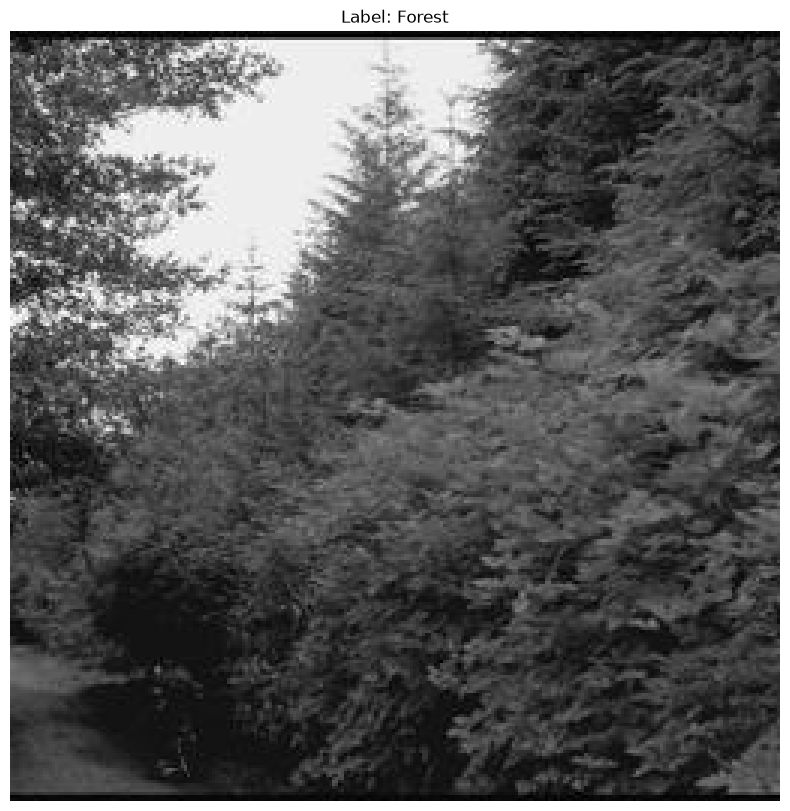

In [152]:
from utils import plot_image
prima_immagine = cv2.imread(str(train_paths[208]), cv2.IMREAD_GRAYSCALE)
plot_image(prima_immagine, f"Label: {train_labels[208]}")

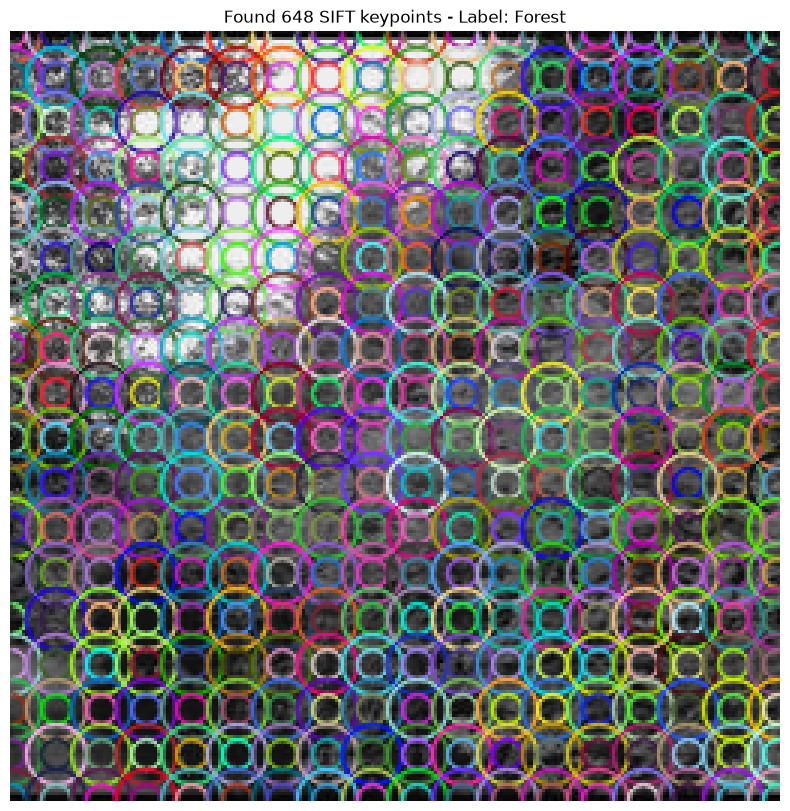

In [153]:
# 1. Take the first image of the list
image_n = 208

immagine_test = cv2.imread(train_paths[image_n], cv2.IMREAD_GRAYSCALE)

# 2. Extract keypoints and descriptors only for it
keypoints_test = all_keypoints[image_n]
descriptors_test = all_descriptors[image_n]

# 3. Draw keypoints on top of the image
# The DRAW_RICH_KEYPOINTS option draws circles with size and orientation
immagine_con_kp = cv2.drawKeypoints(
    immagine_test,
    keypoints_test,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# 4. Show the result
from utils import plot_image
plot_image(immagine_con_kp, f"Found {len(keypoints_test)} SIFT keypoints - Label: {train_labels[image_n]}")

## Sampling of *N_FEATURES* features


In [154]:
# 1. Stack all descriptor arrays vertically into a single matrix
stacked_descriptors = np.vstack(all_descriptors)

total_descriptors = stacked_descriptors.shape[0]
print(f"Total descriptors extracted: {total_descriptors}")

# 2. Set the target number of samples
num_samples = NUM_SAMPLES

# 3. Perform random sampling
if total_descriptors > num_samples:
    print(f"Sampling {num_samples} descriptors randomly...")

    # Generate random row indices without replacement

    random_indices = np.random.choice(total_descriptors, num_samples, replace=False)

    # Filter the original matrix using the random indices
    sampled_descriptors = stacked_descriptors[random_indices, :]

else:
    print("Under the maximum limit, keeping all descriptors.")
    sampled_descriptors = stacked_descriptors

# Final verification (should output (100000, 128))
print(f"Ready for K-Means! Final array shape: {sampled_descriptors.shape}")


Total descriptors extracted: 955426
Sampling 100000 descriptors randomly...
Ready for K-Means! Final array shape: (100000, 128)


## Visual vocabulary creation


In [155]:
# 1. Define the number of clusters (our visual words)
num_clusters = NUM_CLUSTER

print(f"Starting K-Means training with k={num_clusters} (this may take a few minutes)...")
start_time = time.time()

# 2. Initialize the K-Means algorithm
# random_state=42 ensures reproducibility
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)

# 3. Train the model on our sampled data
kmeans.fit(sampled_descriptors)

end_time = time.time()
print(f"K-Means completed in {(end_time - start_time) / 60:.2f} minutes.")

# 4. Extract the centroids (our actual vocabulary)
# It will be a matrix of shape (num_cluster, 128)
visual_vocabulary = kmeans.cluster_centers_
print(f"Shape of visual vocabulary: {visual_vocabulary.shape}")


Starting K-Means training with k=80 (this may take a few minutes)...
K-Means completed in 1.06 minutes.
Shape of visual vocabulary: (80, 128)


## Histogram creation


### Training Histograms


In [156]:
def compute_image_representation(
    image_path,
    sift_detector,
    kmeans_model,
    dense=DENSE,
    spatial_pyramid=SPATIAL_PYRAMID,
    soft_assignment=SOFT_ASSIGNMENT,
    beta=BETA,
):
  """Extracts descriptors from an image and builds the feature vector based on the set parameters:

  - dense: True for Dense SIFT, False for sparse SIFT
  - spatial_pyramid: True for Spatial Pyramid L2 (dimension 21 * K), False for
  global BoW (dimension K)
  - soft_assignment: True for Gaussian weighting, False for Hard Assignment
  """
  image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
  if image is None:
    return None

  h, w = image.shape
  num_clusters = kmeans_model.n_clusters
  # If spatial pyramid is used we multiply the number of clusters by 21 
  # (because we have 1 histogram for the full image, then 4 histograms + 16 histograms due to )
  total_bins = num_clusters * 21 if spatial_pyramid else num_clusters 

  # 1. Keypoint and SIFT Descriptor Extraction
  if dense:
    dense_kp = generate_dense_keypoints((h, w), step_size=15, scales=[10, 20])
    keypoints, descriptors = sift_detector.compute(image, dense_kp)
  else:
    keypoints, descriptors = sift_detector.detectAndCompute(image, None)

  # Safety check: image without features (e.g. flat/homogeneous)
  if descriptors is None or len(descriptors) == 0:
    return np.zeros(total_bins)

  # 2. Quantization (Hard vs Soft Assignment)
  if not soft_assignment:
    # Hard Assignment: index of the nearest centroid
    words = kmeans_model.predict(descriptors)
  else:
    # Soft Assignment: normalized Gaussian exponential weights per descriptor
    centroids = kmeans_model.cluster_centers_
    distances_sq = cdist(descriptors, centroids, metric='sqeuclidean')
    weights = np.exp(-beta * distances_sq)
    row_sums = np.sum(weights, axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0  # Protection against division by zero
    weights = weights / row_sums  # Matrice (N_keypoints, K_cluster)

  # 3. Histogram Construction
  if not spatial_pyramid:
    # --- STANDARD BAG OF WORDS (Global) ---
    if not soft_assignment:
      hist, _ = np.histogram(
          words, bins=num_clusters, range=(0, num_clusters)
      )
      hist = hist.astype(np.float64)
    else:
      hist = np.sum(weights, axis=0)

    # Standard L1 normalization for BoW
    total_mass = np.sum(hist)
    if total_mass > 0:
      hist = hist / total_mass
    return hist

  else:
    # --- SPATIAL PYRAMID (Level 0: 1x1, Level 1: 2x2, Level 2: 4x4) ---
    hist_L0 = np.zeros(num_clusters)
    hist_L1 = np.zeros((4, num_clusters))
    hist_L2 = np.zeros((16, num_clusters))

    if not soft_assignment:
      # Hard Assignment Accumulation
      for kp, word in zip(keypoints, words):
        x, y = kp.pt
        hist_L0[word] += 1

        col_L1 = min(int((x / w) * 2), 1)
        row_L1 = min(int((y / h) * 2), 1)
        hist_L1[row_L1 * 2 + col_L1, word] += 1

        col_L2 = min(int((x / w) * 4), 3)
        row_L2 = min(int((y / h) * 4), 3)
        hist_L2[row_L2 * 4 + col_L2, word] += 1
    else:
      # Soft Assignment Accumulation (distributes the w_vec vector on corresponding cells)
      for kp, w_vec in zip(keypoints, weights):
        x, y = kp.pt
        hist_L0 += w_vec

        col_L1 = min(int((x / w) * 2), 1)
        row_L1 = min(int((y / h) * 2), 1)
        hist_L1[row_L1 * 2 + col_L1] += w_vec

        col_L2 = min(int((x / w) * 4), 3)
        row_L2 = min(int((y / h) * 4), 3)
        hist_L2[row_L2 * 4 + col_L2] += w_vec

    # Standard pyramidal weights of Lazebnik for L=2
    hist_L0 *= 0.25
    hist_L1 *= 0.25
    hist_L2 *= 0.50

    # Concatenation of the 21 histograms
    hists_to_stack = (
        [hist_L0]
        + [hist_L1[i] for i in range(4)]
        + [hist_L2[i] for i in range(16)]
    )
    final_hist = np.concatenate(hists_to_stack)

    # Standard L2 normalization for Spatial Pyramid
    norm = np.linalg.norm(final_hist)
    if norm > 0:
      final_hist = final_hist / norm

    return final_hist

# --- APPLICATION TO THE WHOLE TRAINING SET ---
print('Generation of descriptors for the training set...')
X_train = []
y_train = []

for path, label in zip(train_paths, train_labels):
  feat = compute_image_representation(path, sift, kmeans)
  if feat is not None:
    X_train.append(feat)
    y_train.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f'Done! X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')

Generation of descriptors for the training set...
Done! X_train shape: (1500, 80)
y_train shape: (1500,)


In the previous cell, for computing the soft assignment the following formula is used:

$$w_m(x) = \frac{\exp(-\frac{1}{2\sigma^2} \Vert{}x - c_m\Vert{}^2)}{\sum_{j=1}^{V} \exp(-\frac{1}{2\sigma^2} \Vert{}x - c_j\Vert{}^2)}$$
where $\beta =\frac{1}{2\sigma^2}$,

### Test Histograms


In [ ]:
print("Generation of descriptors for the TEST set...")

X_test = []
y_test = []

for path, label in zip(test_paths, test_labels):
  # Use the same function with the same vocabulary (kmeans)
  feat = compute_image_representation(path, sift, kmeans)
  if feat is not None:
    X_test.append(feat)
    y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"Done! X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Generation of descriptors for the TEST set...


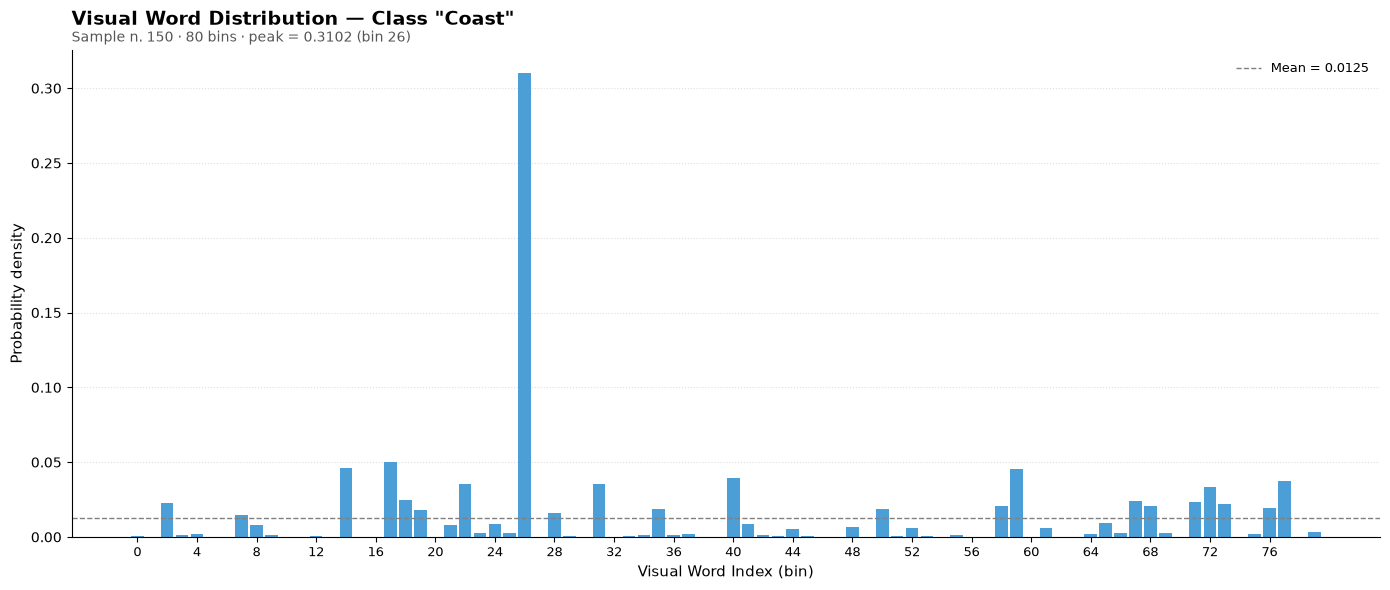

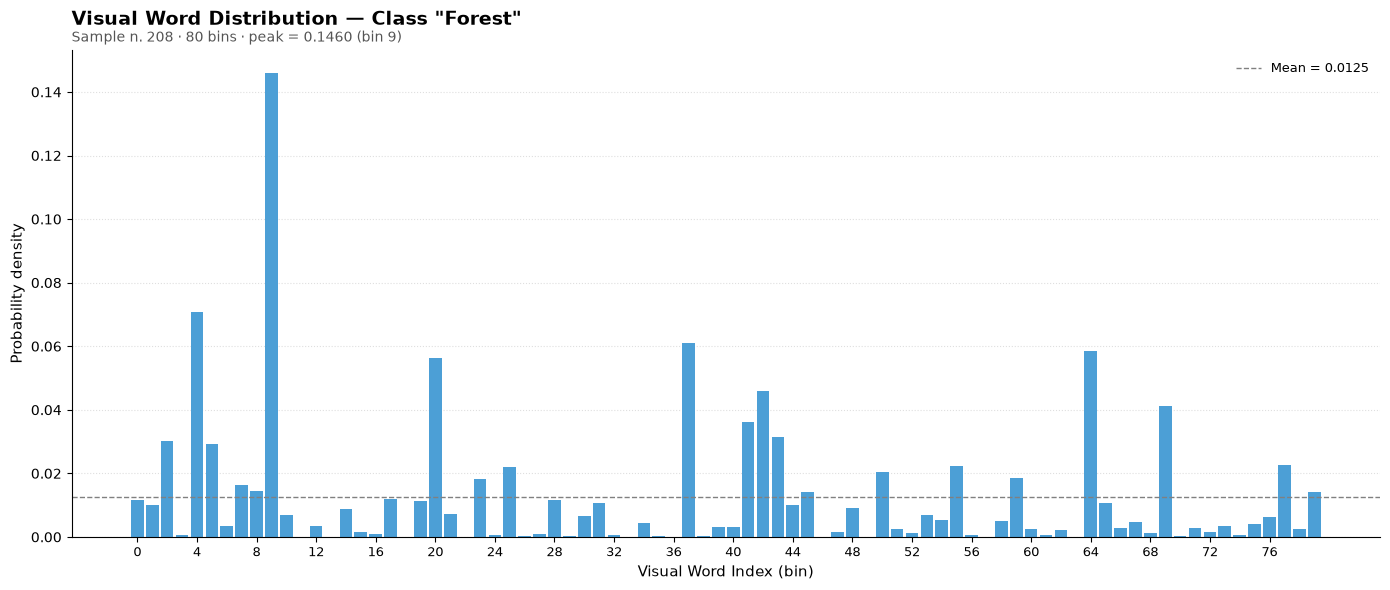

In [ ]:
from utils import plot_hist


# First image
idx = 150
plot_hist(idx, X_train, y_train)

# Second image
idx2 = 208
plot_hist(idx2, X_train, y_train)

## K nearest neighbour


In [ ]:
# 1. Initialize K-Nearest Neighbors (k-NN) classifier
# Using the K_NEIGHBOURS hyperparameter set at the beginning of the notebook
nn_classifier = KNeighborsClassifier(n_neighbors=K_NEIGHBOURS, metric='euclidean')

# 2. Training
print("Training Nearest Neighbor classifier...")
nn_classifier.fit(X_train, y_train)

# 3. Predict on the test set
print("Computing predictions on the test set...")
y_pred_nn = nn_classifier.predict(X_test)

# Compute overall accuracy
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"\n--- NEAREST NEIGHBOR ({K_NEIGHBOURS}-NN) ACCURACY: {accuracy_nn * 100:.2f}% ---")

# 4. Confusion Matrix creation
cm_nn = confusion_matrix(y_test, y_pred_nn, labels=classes)



Training Nearest Neighbor classifier...
Computing predictions on the test set...

--- NEAREST NEIGHBOR (7-NN) ACCURACY: 55.38% ---


### Plotting


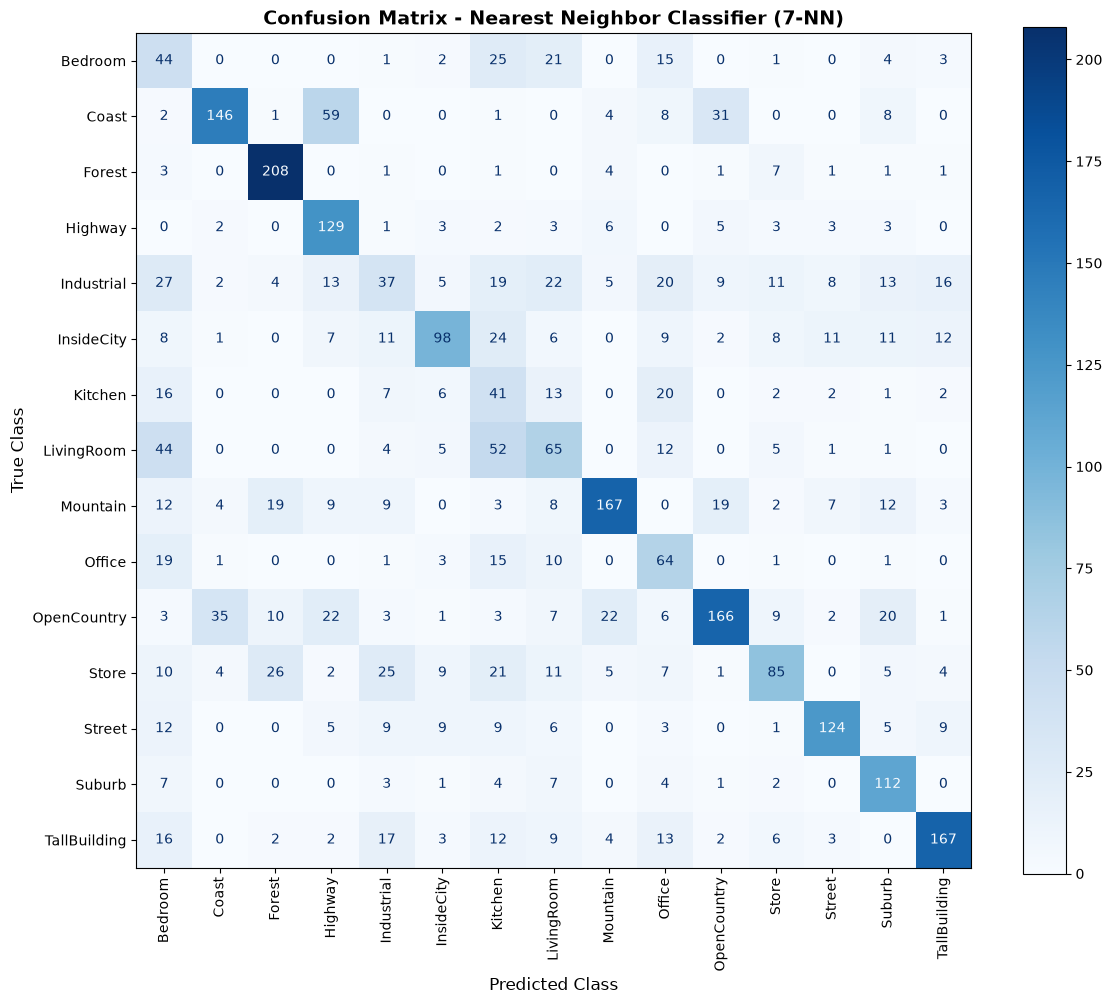

In [ ]:
# 5. Confusion Matrix visualization
from utils import plot_confusion_matrix
plot_confusion_matrix(cm_nn, classes, f"Confusion Matrix - Nearest Neighbor Classifier ({K_NEIGHBOURS}-NN)")


## SVM


In [ ]:
from sklearn.svm import SVC

print("\n--- LINEAR SVM TRAINING AND EVALUATION (One-vs-Rest) ---")

# --- Train multiclass Linear SVM (One-vs-Rest) ---
svm_classifier = SVC(C = 30, kernel='linear', decision_function_shape='ovr', random_state=42)

print("Training Linear SVM...")
start_time_svm = time.time()
svm_classifier.fit(X_train, y_train)
print(f"SVM trained in {(time.time() - start_time_svm):.2f} seconds.")

# --- Evaluate multiclass SVM ---
print("Computing real-valued decision scores...")

# Compute decision function scores
decision_scores = svm_classifier.decision_function(X_test)

# Assign class corresponding to the maximum decision score
predicted_indices = np.argmax(decision_scores, axis=1)

y_pred_svm = svm_classifier.classes_[predicted_indices]

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\n--- SVM ACCURACY: {accuracy_svm * 100:.2f}% ---")

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=classes)




--- LINEAR SVM TRAINING AND EVALUATION (One-vs-Rest) ---
Training Linear SVM...
SVM trained in 0.10 seconds.
Computing real-valued decision scores...

--- SVM ACCURACY: 68.34% ---


### Plotting


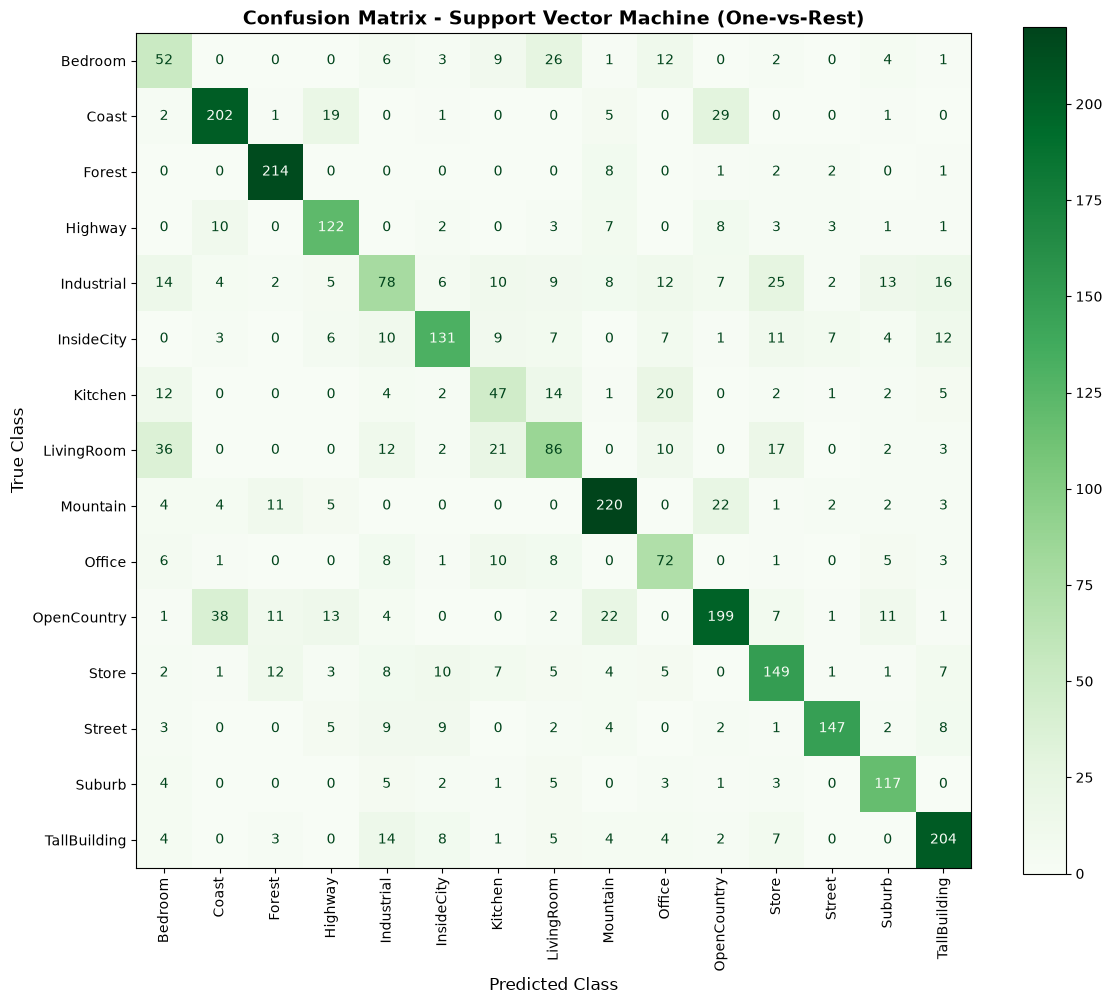

In [ ]:
# --- CONFUSION MATRIX VISUALIZATION ---
from utils import plot_confusion_matrix
plot_confusion_matrix(cm_svm, classes, "Confusion Matrix - Support Vector Machine (One-vs-Rest)", cmap='Greens')


## SVM with CHI SQUARED

Point 6


In [ ]:
# --- SVM TRAINING WITH CHI SQUARDE KERNEL ---
print("Training SVM with Chi squared Kernel...")

def chi2_kernel(X, Y, gamma=1.0):
    result = np.zeros((X.shape[0], Y.shape[0]))
    for i, x in enumerate(X):
        for j, y in enumerate(Y):
            denom = x + y
            denom[denom == 0] = 1e-10  # avoid division by zero
            result[i, j] = np.exp(-gamma * np.sum((x - y)**2 / denom))
    return result


svm_chi2 = SVC(C= 5, kernel=lambda X, Y: chi2_kernel(X, Y, gamma=0.5), random_state=42)
svm_chi2.fit(X_train, y_train)

print("Training complete!")

# --- EVALUATION ON TEST SET ---
print("Evaluating on test set...")
y_pred_chi = svm_chi2.predict(X_test)

acc_chi2 = accuracy_score(y_test, y_pred_chi)
print(f"Gaussian SVM Accuracy: {acc_chi2 * 100:.2f}%")

cm_chi2 = confusion_matrix(y_test, y_pred_chi, labels=classes)
disp_chi2 = ConfusionMatrixDisplay(confusion_matrix=cm_chi2, display_labels=classes)



Training SVM with Chi squared Kernel...
Training complete!
Evaluating on test set...
Gaussian SVM Accuracy: 71.49%


### Plotting


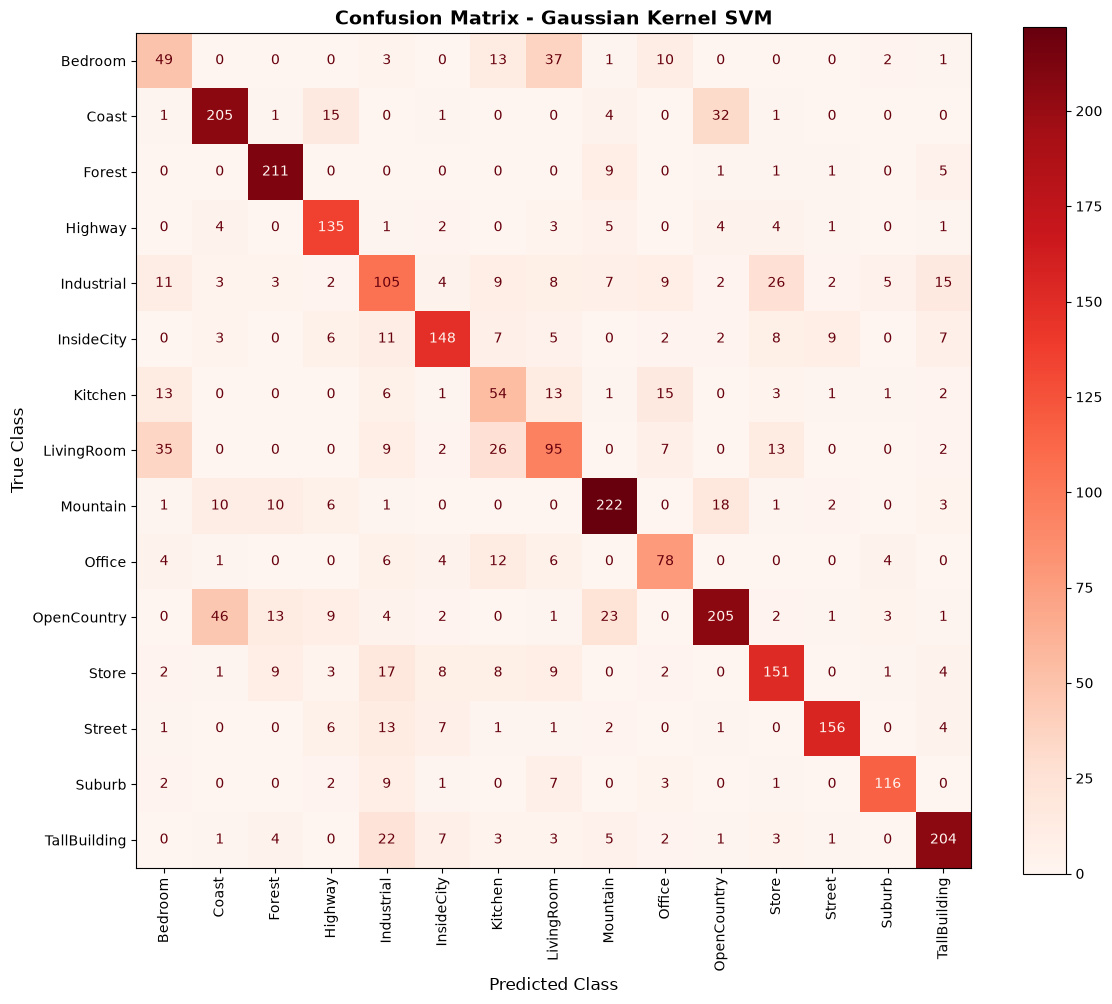

In [ ]:
from utils import plot_confusion_matrix
plot_confusion_matrix(cm_chi2, classes, "Confusion Matrix - Gaussian Kernel SVM",cmap='Reds')


## Multiclass SVM using the Error Correcting Output Code approach

Point 7


In [ ]:
from sklearn.multiclass import OutputCodeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print("Configuring ECOC classifier with Gaussian SVM (RBF)...")

base_svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

ecoc_pipeline = make_pipeline(
    StandardScaler(),
    OutputCodeClassifier(estimator=base_svm, code_size=1.5, random_state=42),
)

# --- 2. TRAINING ---
print("Starting ECOC model training...")
ecoc_pipeline.fit(X_train, y_train)
print("Training completed successfully!")

# --- 3. PREDICTIONS ON TEST SET ---
print("Computing predictions on test set...")
y_pred_ecoc = ecoc_pipeline.predict(X_test)

# --- 4. EVALUATION AND ACCURACY ---
acc_ecoc = accuracy_score(y_test, y_pred_ecoc)
print(f"Overall ECOC-SVM Model Accuracy: {acc_ecoc * 100:.2f}%")

# --- 5. CONFUSION MATRIX COMPUTATION AND DISPLAY ---
print("Generating confusion matrix...")
cm_ecoc = confusion_matrix(y_test, y_pred_ecoc, labels=classes)



Configuring ECOC classifier with Gaussian SVM (RBF)...
Starting ECOC model training...
Training completed successfully!
Computing predictions on test set...
Overall ECOC-SVM Model Accuracy: 66.70%
Generating confusion matrix...


### Plotting


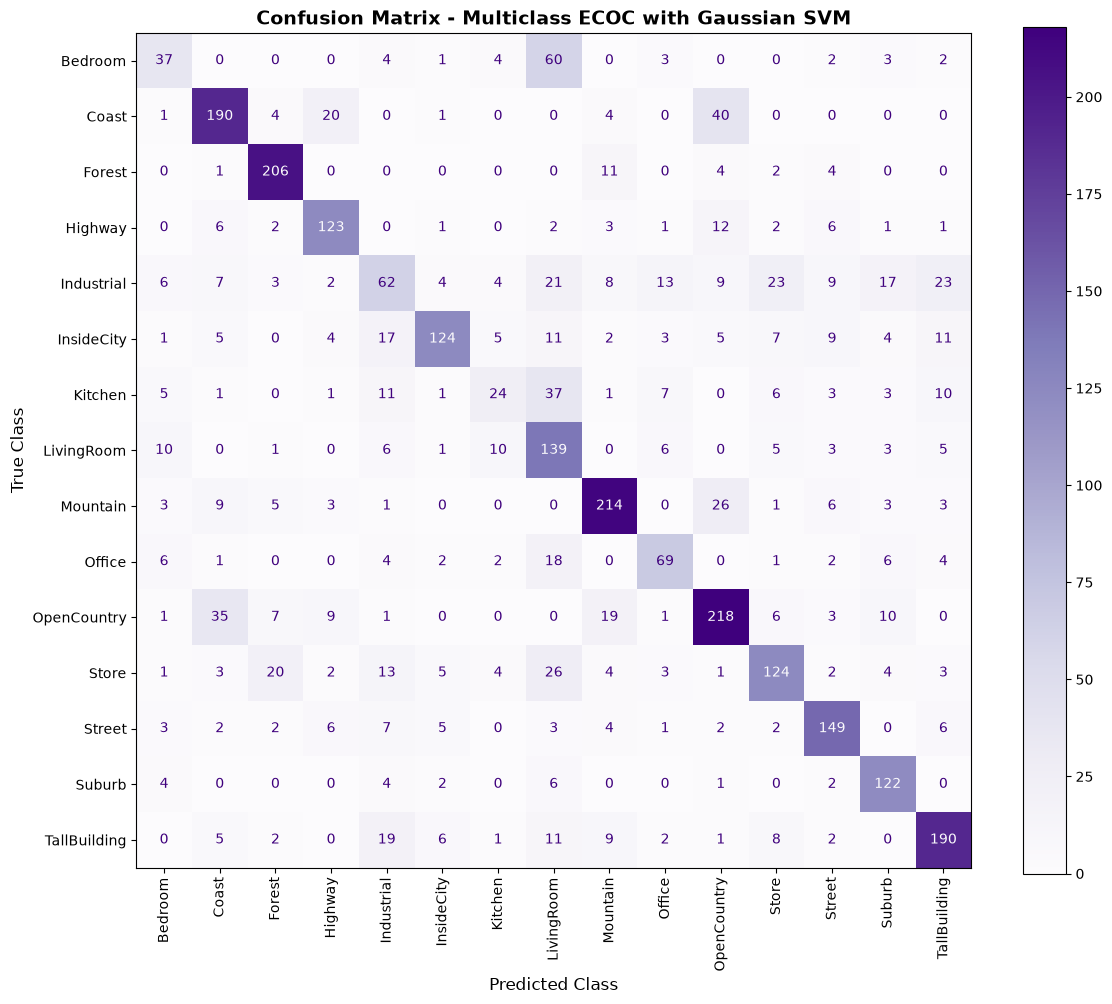

In [ ]:
from utils import plot_confusion_matrix
plot_confusion_matrix(cm_ecoc, classes, "Confusion Matrix - Multiclass ECOC with Gaussian SVM", cmap='Purples')
